# Token Efficiency in FeatureLiftBench Agents

## tl;dr

This notebook audits 550 Python OpenHands task runs: four models on core-100 and
three models on hard50. It asks whether token consumption is a useful target for
method innovation and which optimizations are scientifically defensible.

The primary outcome is the composite suite result (`run_status == passed`), not
evaluator-only functional success. Token comparisons across different tokenizer
families are descriptive; matched Qwen3.6 comparisons are the strongest
cross-model efficiency evidence.

## Context & Methods

### Key assumptions

- Every assigned task remains in the denominator; missing submissions count as failures.
- `total_tokens = prompt_tokens + completion_tokens` is proxy-verified usage.
- Repeated reads and context-growth estimates are diagnostic associations, not causal waste estimates.
- A simulated context cap is an upper-bound savings calculation. It does not predict pass rate under compression.
- Agent-observed public success is recovered from event timestamps; final public/hidden results come from the evaluator.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "trajectory_records_550.csv").is_file():
    REPORT_DIR = CURRENT_DIR
    REPO_ROOT = REPORT_DIR.parents[1]
else:
    REPO_ROOT = CURRENT_DIR
    REPORT_DIR = REPO_ROOT / "reports" / "token_efficiency_20260720"
CSV_PATH = REPORT_DIR / "trajectory_records_550.csv"

raw = pd.read_csv(CSV_PATH, keep_default_na=False)
numeric_columns = [
    "total_tokens", "prompt_tokens", "completion_tokens", "api_calls",
    "assistant_steps", "repeated_file_reads", "repeated_line_reads",
    "repeated_terminal_commands", "final_score", "extraction_ratio",
]
for column in numeric_columns:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

for column in [
    "functional_pass", "events_available", "evaluation_available",
    "public_pass", "hidden_pass",
]:
    raw[column] = raw[column].astype(str).str.lower().eq("true")

raw["formal_pass"] = raw["run_status"].eq("passed")
raw["evaluator_functional_pass"] = raw["functional_pass"]
raw["repeated_exploration"] = raw["repeated_file_reads"].fillna(0).gt(0)
raw["outcome"] = np.where(raw["formal_pass"], "passed", "not passed")
raw.shape

(550, 63)

## Data quality checks

In [2]:
quality = {
    "rows": len(raw),
    "unique_model_task_pairs": raw[["model", "task_id"]].drop_duplicates().shape[0],
    "token_complete_rows": int(raw["total_tokens"].notna().sum()),
    "event_complete_rows": int(raw["events_available"].sum()),
    "evaluation_complete_rows": int(raw["evaluation_available"].sum()),
    "token_identity_mismatches": int(
        (raw["total_tokens"] != raw["prompt_tokens"] + raw["completion_tokens"]).sum()
    ),
}
quality

{'rows': 550,
 'unique_model_task_pairs': 550,
 'token_complete_rows': 550,
 'event_complete_rows': 550,
 'evaluation_complete_rows': 533,
 'token_identity_mismatches': 0}

In [3]:
assert quality == {
    "rows": 550,
    "unique_model_task_pairs": 550,
    "token_complete_rows": 550,
    "event_complete_rows": 550,
    "evaluation_complete_rows": 533,
    "token_identity_mismatches": 0,
}
raw.groupby(["model", "split"], as_index=False).agg(
    tasks=("task_id", "size"),
    formal_passes=("formal_pass", "sum"),
    missing_submissions=("run_status", lambda values: int((values == "missing_submission").sum())),
)

,model,split,tasks,formal_passes,missing_submissions
0,deepseek/deepseek-v4-flash,core100,100,83,2
1,deepseek/deepseek-v4-flash,hard50,50,8,1
2,openai/Qwen3-Coder-30B-A3B-Instruct,core100,100,24,0
3,openai/Qwen3.6-27B-FP8,core100,100,54,2
4,openai/Qwen3.6-27B-FP8,hard50,50,4,6
5,openai/Qwen3.6-35B-A3B-FP8,core100,100,49,5
6,openai/Qwen3.6-35B-A3B-FP8,hard50,50,3,1


## Results

In [4]:
def q90(values: pd.Series) -> float:
    return float(values.quantile(0.90))


model_summary = raw.groupby("model", as_index=False).agg(
    tasks=("task_id", "size"),
    passes=("formal_pass", "sum"),
    total_tokens=("total_tokens", "sum"),
    median_tokens=("total_tokens", "median"),
    p90_tokens=("total_tokens", q90),
    prompt_tokens=("prompt_tokens", "sum"),
    completion_tokens=("completion_tokens", "sum"),
)
model_summary["pass_rate"] = model_summary["passes"] / model_summary["tasks"]
model_summary["tokens_per_pass"] = model_summary["total_tokens"] / model_summary["passes"]
model_summary["unsuccessful_token_share"] = model_summary["model"].map(
    raw.loc[~raw["formal_pass"]].groupby("model")["total_tokens"].sum()
) / model_summary["total_tokens"]
model_summary

,model,tasks,passes,total_tokens,median_tokens,p90_tokens,prompt_tokens,completion_tokens,pass_rate,tokens_per_pass,unsuccessful_token_share
0,deepseek/deepseek-v4-flash,150,91,319414746,1649321.0,4022055.7,314501281,4913465,0.606667,3.510052e+06,0.366939
1,openai/Qwen3-Coder-30B-A3B-Instruct,100,24,216836907,2020808.0,3877383.6,213975953,2860954,0.240000,9.034871e+06,0.855704
2,openai/Qwen3.6-27B-FP8,150,58,257390841,1126577.0,4304195.2,254758361,2632480,0.386667,4.437773e+06,0.694696
3,openai/Qwen3.6-35B-A3B-FP8,150,52,298387703,1500339.5,3737277.4,294086783,4300920,0.346667,5.738225e+06,0.717999


In [5]:
headline = {
    "runs": len(raw),
    "formal_passes": int(raw["formal_pass"].sum()),
    "total_tokens": int(raw["total_tokens"].sum()),
    "prompt_token_share": float(raw["prompt_tokens"].sum() / raw["total_tokens"].sum()),
    "unsuccessful_token_share": float(
        raw.loc[~raw["formal_pass"], "total_tokens"].sum() / raw["total_tokens"].sum()
    ),
    "repeated_read_run_share": float(raw["repeated_exploration"].mean()),
    "median_tokens_repeated": float(
        raw.loc[raw["repeated_exploration"], "total_tokens"].median()
    ),
    "median_tokens_no_repeat": float(
        raw.loc[~raw["repeated_exploration"], "total_tokens"].median()
    ),
}
headline

{'runs': 550,
 'formal_passes': 225,
 'total_tokens': 1092030197,
 'prompt_token_share': 0.9865316737207406,
 'unsuccessful_token_share': 0.6371661625397342,
 'repeated_read_run_share': 0.6527272727272727,
 'median_tokens_repeated': 2083304.0,
 'median_tokens_no_repeat': 757788.0}

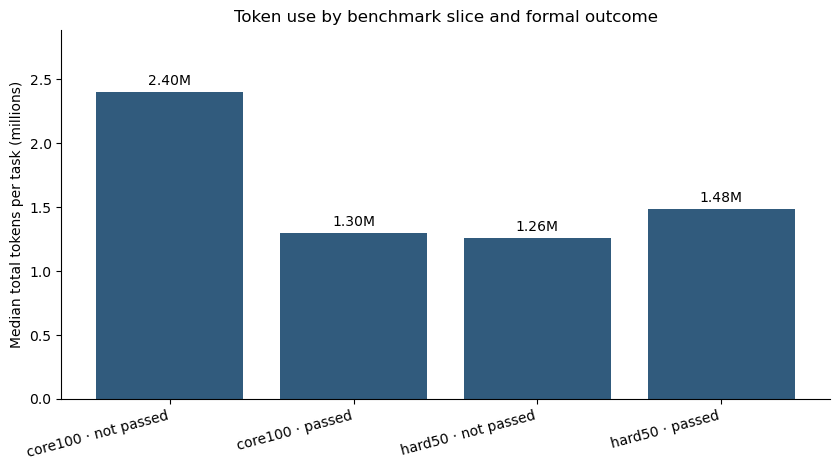

,split,outcome,tasks,median_tokens,mean_tokens,total_tokens
0,core100,not passed,190,2403136.5,2.623263e+06,498420029
1,core100,passed,210,1300732.0,1.760017e+06,369603672
2,hard50,not passed,135,1256277.0,1.462109e+06,197384661
3,hard50,passed,15,1483351.0,1.774789e+06,26621835


In [6]:
outcome_summary = raw.groupby(["split", "outcome"], as_index=False).agg(
    tasks=("task_id", "size"),
    median_tokens=("total_tokens", "median"),
    mean_tokens=("total_tokens", "mean"),
    total_tokens=("total_tokens", "sum"),
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
labels = outcome_summary["split"] + " · " + outcome_summary["outcome"]
bars = ax.bar(labels, outcome_summary["median_tokens"] / 1_000_000, color="#315b7d")
ax.set_ylabel("Median total tokens per task (millions)")
ax.set_title("Token use by benchmark slice and formal outcome")
ax.set_ylim(0, max(outcome_summary["median_tokens"] / 1_000_000) * 1.2)
ax.bar_label(bars, fmt="%.2fM", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()
outcome_summary

Core-100 failures consume substantially more tokens than passes, while hard50
failures often stop earlier. Therefore a universal hard cap would affect the two
slices differently and cannot be justified from aggregate token counts alone.

In [7]:
budget_rows = []
total_observed_tokens = raw["total_tokens"].sum()
for cap in [500_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000, 6_000_000]:
    over = raw["total_tokens"] > cap
    savings_upper = (raw["total_tokens"] - cap).clip(lower=0).sum()
    budget_rows.append(
        {
            "cap_tokens": cap,
            "runs_over_cap": int(over.sum()),
            "run_share_over_cap": float(over.mean()),
            "savings_upper_tokens": int(savings_upper),
            "savings_upper_share": float(savings_upper / total_observed_tokens),
            "observed_passes_over_cap": int((over & raw["formal_pass"]).sum()),
            "observed_pass_share_over_cap": float(
                (over & raw["formal_pass"]).sum() / raw["formal_pass"].sum()
            ),
        }
    )
budget_sensitivity = pd.DataFrame(budget_rows)
budget_sensitivity

,cap_tokens,runs_over_cap,run_share_over_cap,savings_upper_tokens,savings_upper_share,observed_passes_over_cap,observed_pass_share_over_cap
0,500000,488,0.887273,826567148,0.756909,192,0.853333
1,1000000,368,0.669091,611490737,0.559958,136,0.604444
2,1500000,282,0.512727,447060534,0.409385,99,0.440000
3,2000000,207,0.376364,326474520,0.298961,64,0.284444
4,3000000,107,0.194545,171838176,0.157357,29,0.128889
5,6000000,9,0.016364,47786959,0.043760,6,0.026667


A hard cap is not a valid counterfactual: at 1.5M tokens it intersects many
currently successful trajectories. The table only sizes the theoretical token
opportunity and the observed-success population at risk. A real intervention
must be rerun under the cap.

In [8]:
from datetime import datetime


def parse_time(value: str) -> datetime:
    return datetime.fromisoformat(value.replace("Z", "+00:00")).replace(tzinfo=None)


context_rows = []
post_public_rows = []
for row in raw.to_dict("records"):
    run_path = REPO_ROOT / row["run_path"]
    audit_path = run_path.parent / "agent" / "context_audit.jsonl"
    calls = []
    if audit_path.is_file():
        for line in audit_path.read_text(encoding="utf-8").splitlines():
            payload = json.loads(line)
            if payload.get("status") == 200 and isinstance(payload.get("prompt_tokens"), int):
                calls.append(payload)
    if not calls:
        continue

    first_prompt = calls[0]["prompt_tokens"]
    context_rows.append(
        {
            "model": row["model"],
            "task_id": row["task_id"],
            "formal_pass": row["formal_pass"],
            "calls": len(calls),
            "observed_prompt_tokens": sum(call["prompt_tokens"] for call in calls),
            "history_growth_upper_tokens": sum(call["prompt_tokens"] for call in calls)
            - len(calls) * first_prompt,
            **{
                f"capped_{cap}": sum(min(call["prompt_tokens"], cap) for call in calls)
                for cap in [16_000, 24_000, 32_000, 48_000, 64_000]
            },
        }
    )

    public_step_id = row["public_success_step_id"]
    event_path = REPO_ROOT / row["trajectory_path"]
    public_time = None
    if public_step_id and event_path.is_file():
        for line in event_path.read_text(encoding="utf-8").splitlines():
            event = json.loads(line)
            if event.get("id") == public_step_id:
                public_time = parse_time(event["timestamp"])
                break
    if public_time is not None:
        after = [
            call for call in calls
            if call.get("timestamp") and parse_time(call["timestamp"]) > public_time
        ]
        post_public_rows.append(
            {
                "model": row["model"],
                "task_id": row["task_id"],
                "formal_pass": row["formal_pass"],
                "public_hidden_fail": row["public_pass"] and not row["hidden_pass"],
                "total_call_tokens": sum(call.get("total_tokens", 0) for call in calls),
                "post_public_tokens": sum(call.get("total_tokens", 0) for call in after),
                "post_public_calls": len(after),
            }
        )

context = pd.DataFrame(context_rows)
post_public = pd.DataFrame(post_public_rows)
len(context), len(post_public)

(550, 498)

In [9]:
observed_prompt = context["observed_prompt_tokens"].sum()
context_cap_rows = []
for cap in [16_000, 24_000, 32_000, 48_000, 64_000]:
    capped = context[f"capped_{cap}"].sum()
    context_cap_rows.append(
        {
            "per_call_prompt_cap": cap,
            "potential_prompt_savings": int(observed_prompt - capped),
            "potential_prompt_savings_share": float((observed_prompt - capped) / observed_prompt),
            "affected_runs": int((context[f"capped_{cap}"] < context["observed_prompt_tokens"]).sum()),
            "affected_observed_passes": int(
                ((context[f"capped_{cap}"] < context["observed_prompt_tokens"]) & context["formal_pass"]).sum()
            ),
        }
    )
context_cap_sensitivity = pd.DataFrame(context_cap_rows)
context_growth = {
    "observed_prompt_tokens": int(observed_prompt),
    "history_growth_upper_tokens": int(context["history_growth_upper_tokens"].sum()),
    "history_growth_upper_share": float(
        context["history_growth_upper_tokens"].sum() / observed_prompt
    ),
}
context_growth, context_cap_sensitivity

({'observed_prompt_tokens': 1077322378,
  'history_growth_upper_tokens': 725424805,
  'history_growth_upper_share': 0.673359079709008},
    per_call_prompt_cap  potential_prompt_savings  \
 0                16000                 601478935   
 1                24000                 412313159   
 2                32000                 271201627   
 3                48000                 108522226   
 4                64000                  43433056   
 
    potential_prompt_savings_share  affected_runs  affected_observed_passes  
 0                        0.558309            547                       225  
 1                        0.382720            509                       198  
 2                        0.251737            459                       179  
 3                        0.100733            322                       126  
 4                        0.040316            155                        60  )

In [10]:
post_public["post_public_share"] = (
    post_public["post_public_tokens"] / post_public["total_call_tokens"]
)
post_public_summary = pd.DataFrame(
    [
        {
            "cohort": "all agent-observed public successes",
            "runs": len(post_public),
            "aggregate_post_public_share": post_public["post_public_tokens"].sum()
            / post_public["total_call_tokens"].sum(),
            "median_post_public_share": post_public["post_public_share"].median(),
            "median_post_public_calls": post_public["post_public_calls"].median(),
        },
        {
            "cohort": "formal passes",
            "runs": int(post_public["formal_pass"].sum()),
            "aggregate_post_public_share": post_public.loc[post_public["formal_pass"], "post_public_tokens"].sum()
            / post_public.loc[post_public["formal_pass"], "total_call_tokens"].sum(),
            "median_post_public_share": post_public.loc[post_public["formal_pass"], "post_public_share"].median(),
            "median_post_public_calls": post_public.loc[post_public["formal_pass"], "post_public_calls"].median(),
        },
        {
            "cohort": "evaluator public-pass / hidden-fail",
            "runs": int(post_public["public_hidden_fail"].sum()),
            "aggregate_post_public_share": post_public.loc[post_public["public_hidden_fail"], "post_public_tokens"].sum()
            / post_public.loc[post_public["public_hidden_fail"], "total_call_tokens"].sum(),
            "median_post_public_share": post_public.loc[post_public["public_hidden_fail"], "post_public_share"].median(),
            "median_post_public_calls": post_public.loc[post_public["public_hidden_fail"], "post_public_calls"].median(),
        },
    ]
)
post_public_summary

,cohort,runs,aggregate_post_public_share,median_post_public_share,median_post_public_calls
0,all agent-observed public successes,498,0.155273,0.119446,4.0
1,formal passes,223,0.099889,0.137144,4.0
2,evaluator public-pass / hidden-fail,171,0.092670,0.087681,3.0


The evidence does not support an early-stop optimization immediately after the
first public pass. Public-to-hidden failures spend a smaller share of tokens
after the first observed public success than final passes. Token optimization
should compact and reuse evidence while preserving a freshness-aware final
verification phase.

## Takeaways

In [11]:
qwen = model_summary[model_summary["model"].str.contains("Qwen3.6")].copy()
qwen_efficiency = qwen[["model", "tasks", "passes", "total_tokens", "tokens_per_pass"]]
qwen_efficiency

,model,tasks,passes,total_tokens,tokens_per_pass
2,openai/Qwen3.6-27B-FP8,150,58,257390841,4.437773e+06
3,openai/Qwen3.6-35B-A3B-FP8,150,52,298387703,5.738225e+06


1. The current agent is token-inefficient, but the dominant mechanism is prompt-history replay and repeated exploration, not completion verbosity.
2. More tokens are not automatically useful: Qwen3.6-35B consumes more matched-task tokens than Qwen3.6-27B while passing fewer tasks.
3. Naive hard caps are unsafe because many observed passes exceed common caps.
4. The defensible method direction is evidence-preserving memory plus a residual-risk controller, evaluated at matched budgets.
5. Report a pass/compactness/token Pareto frontier rather than collapsing quality and cost into one gameable score.

In [12]:
summary = {
    "quality": quality,
    "headline": headline,
    "context_growth": context_growth,
    "agent_observed_public_success_runs": int(len(post_public)),
    "evaluator_public_pass_hidden_fail_runs": int(
        (raw["public_pass"] & ~raw["hidden_pass"]).sum()
    ),
}

model_summary.to_csv(REPORT_DIR / "model_summary.csv", index=False)
outcome_summary.to_csv(REPORT_DIR / "outcome_summary.csv", index=False)
budget_sensitivity.to_csv(REPORT_DIR / "budget_cap_sensitivity.csv", index=False)
context_cap_sensitivity.to_csv(REPORT_DIR / "context_cap_sensitivity.csv", index=False)
post_public_summary.to_csv(REPORT_DIR / "post_public_summary.csv", index=False)
(REPORT_DIR / "analysis_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)
summary

{'quality': {'rows': 550,
  'unique_model_task_pairs': 550,
  'token_complete_rows': 550,
  'event_complete_rows': 550,
  'evaluation_complete_rows': 533,
  'token_identity_mismatches': 0},
 'headline': {'runs': 550,
  'formal_passes': 225,
  'total_tokens': 1092030197,
  'prompt_token_share': 0.9865316737207406,
  'unsuccessful_token_share': 0.6371661625397342,
  'repeated_read_run_share': 0.6527272727272727,
  'median_tokens_repeated': 2083304.0,
  'median_tokens_no_repeat': 757788.0},
 'context_growth': {'observed_prompt_tokens': 1077322378,
  'history_growth_upper_tokens': 725424805,
  'history_growth_upper_share': 0.673359079709008},
 'agent_observed_public_success_runs': 498,
 'evaluator_public_pass_hidden_fail_runs': 173}